In [1]:
import pandas as pd 

df = pd.read_csv("../../data/election.txt", sep="\t")

# Linear Regression 
In this article I'll dive into linear regression. 

Linear regression is a statistical method used to model the relationship between a dependent variable (y) and one or more independent variables (x). It is based on the assumption that the relationship between the variables is linear, meaning that the change in y is proportional to the change in x.

A simple linear regression model is given by:

$$
y = \beta_0 + \beta_1 x + \epsilon
$$

The formula commonly used for simple regressions is the **least squares** method

## Residuals
Residuals are the difference between value of a $y$ and the predicted value of $\hat y$.

$$
\epsilon = y - \hat y
$$

![Residuals](assets/residuals.png)

## A line of correlation
In algebra, a line is written as:
$$
y = mx + b 
$$
In statistics a similar but slightly different formula is used:
$$
y = \beta_0 + \beta_1 x
$$
The *b’*s are coefficients of the linear model. $b_1$ is the **slope**, and $b_1$ is the **y-intercept.**
This is basically done to save on letters of the alphabet as models can become larger.
### Slope
$$
\beta_1=r\frac{s_y}{s_x}
$$
This form show the relationship between the slope and correlation. 
However, it often calculated (resulting in the same value) with:
$$
\beta_1=\frac{\Sigma(x_i-\bar x)(y_i- \bar y)}{\Sigma(x_i- \bar x)}
$$

### Y-Intercept 
Because the mean $\bar y$ can be written as:
$$
\bar y=\beta_0+\beta_1x
$$
It can be rearranged as:
$$
\beta_0 = \bar y -\beta_1 \bar x
$$

## Regression to the mean
If we think in *Z-scores*  the relationship is remarkably simple:

When the correlation between x and *y* is *r* - and *x* has a z-score of $z_x$the predicted value of *y* is just $\hat z_y= rz_x$

This is because $b_0 = \bar y - b_1\hat x$, so if using z-scores $\bar y = 0$, and the slope $b_1=r\frac{s_y}{s_x}$ - for standardized variables $s_y, s_x$ both equal 1, so $b_1= r$. In other words $\hat z_y= rz_x$.

![Regression](assets/linear-regression.png)
While we rarely standardize variables to do a regression, we can think about what the z-score regression means. It says that when the correlation is r, and an x-value lies k standard deviations from its mean, our prediction for y is $r * k$ standard deviations from its mean

<aside style="background-color: #f9f9f9; border-left: 4px solid #ccc; padding: 10px;">
  <strong>Note:</strong> This has a profound consequence: 
    <p>For linear relationships, you can never predict that $y$ will be farther from the mean than $x$ was from its mean. </p
</aside>


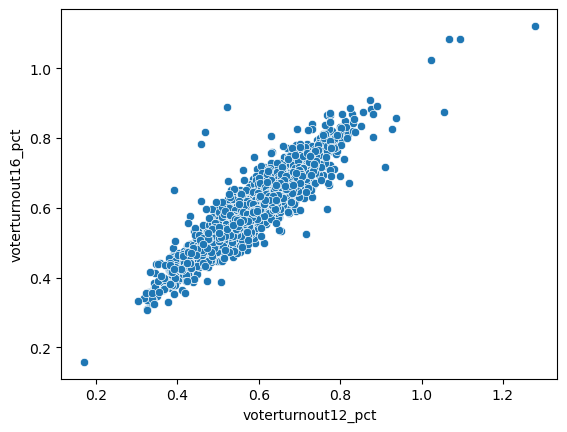

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(df, x="voterturnout12_pct", y="voterturnout16_pct")
plt.show()

y = 0.08 + 0.90x


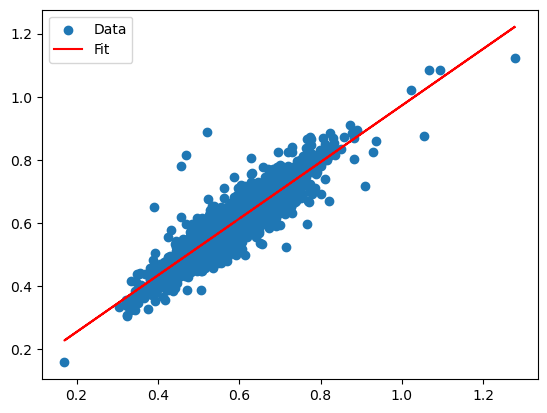

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_12 = df["voterturnout12_pct"]
y_16 = df["voterturnout16_pct"]

x_mean = np.mean(x_12)
y_mean = np.mean(y_16)

# Calculate b1 (slope)
b1 = np.sum((x_12 - x_mean) * (y_16 - y_mean)) / np.sum((x_12 - x_mean)**2)

# Calculate b0 (intercept)
b0 = y_mean - b1 * x_mean

# Predicted y
y_pred = b0 + b1 * x_12

# Print equation
print(f"y = {b0:.2f} + {b1:.2f}x")

# Plot
plt.scatter(x_12, y_16, label='Data')
plt.plot(x_12, y_pred, color='red', label='Fit')
plt.legend()
plt.show()


In [ ]:
# plot the residuals


## Plot the residuals
It is often a good idea to plot the residuals, finding patterns in these might help inform further research on variable relationships and/or help us improve our regression algorithm.
We often plot the residuals, hoping to find ‘nothing interesting’

This can give us the **Equal Variance Assumption.** The condition to check is the **Does the Plot Thicken? Condition.** We ask if the plot thickens because the usual violation to the assumption is that the spread increases as x or the predicted values increase

![residual plot](/assets/residuals-bk.png)

## Residual Standard Deviation
The standard deviation of the residuals $s_e$ gives us a measure of how much the points spread around the regression line. 
$$
s_e = \sqrt \frac{\Sigma e^2}{n-2}
$$
We don’t need to subtract the mean because the mean of the residuals $e = 0$. 

## $R^2$ - The Variation Accounted for by the Model
We can get a measure of how well the model accounts for variablity in the data by squaring the correlation. 
For the Burger King model, r2 = 0.762 = 0.58, and 1 - r2 is 0.42, so 42% of the variability in total Fat has been left in the residuals. 
According to our linear model, 58% of the variability in the fat content of Burger King items is accounted for by variation in the protein content.
#### How Can We See That R2 Is Really the Fraction of Variance Accounted for by the Model?
It’s a simple calculation. The variance of the fat content of the Burger King foods is 16.22 = 262.44. If we treat the residuals as data, the variance of the residuals is 110.53.9 As a fraction, that’s $110.53/262.44 = 0.42$ or 42,. That’s the fraction of the variance that is not accounted for by the model. The fraction that is accounted for is $1 - 0.42 = 0.58$ or 100%, just the value we got for R2.
